In [4]:
import tensorflow.keras as keras
import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import uproot
import tensorflow

In [5]:
import yaml

with open('definitions.yml') as file:
    # The FullLoader parameter handles the conversion from YAML
    # scalar values to Python the dictionary format
    definitions = yaml.load(file, Loader=yaml.FullLoader)
    
features = definitions['features']
spectators = definitions['spectators']
labels = definitions['labels']

nfeatures = definitions['nfeatures']
nspectators = definitions['nspectators']
nlabels = definitions['nlabels']
ntracks = definitions['ntracks']

In [6]:
from DataGenerator import DataGenerator
help(DataGenerator)

Help on class DataGenerator in module DataGenerator:

class DataGenerator(keras.src.trainers.data_adapters.py_dataset_adapter.PyDataset)
 |  DataGenerator(list_files, features, labels, spectators, batch_size=1024, n_dim=60, remove_mass_pt_window=False, remove_unlabeled=True, return_spectators=False, max_entry=20000, scale_mass_pt=[1, 1])
 |
 |  Generates data for Keras
 |
 |  Method resolution order:
 |      DataGenerator
 |      keras.src.trainers.data_adapters.py_dataset_adapter.PyDataset
 |      builtins.object
 |
 |  Methods defined here:
 |
 |  __getitem__(self, index)
 |      Generate one batch of data
 |
 |  __init__(self, list_files, features, labels, spectators, batch_size=1024, n_dim=60, remove_mass_pt_window=False, remove_unlabeled=True, return_spectators=False, max_entry=20000, scale_mass_pt=[1, 1])
 |      Initialization
 |
 |  __len__(self)
 |      Denotes the number of batches per epoch
 |
 |  on_epoch_end(self)
 |      Updates indexes after each epoch
 |
 |  -----------

## Training Data and Validation Data
- Training data can be downloaded from:
root://eospublic.cern.ch//eos/opendata/cms/datascience/HiggsToBBNtupleProducerTool/HiggsToBBNTuple_HiggsToBB_QCD_RunII_13TeV_MC/train/ntuple_merged_10.root
- Validation data can be downloaded from:
root://eospublic.cern.ch//eos/opendata/cms/datascience/HiggsToBBNtupleProducerTool/HiggsToBBNTuple_HiggsToBB_QCD_RunII_13TeV_MC/train/ntuple_merged_11.root

In [7]:
# load training and validation generators 
train_files = ['ntuple_merged_10_train.root']
val_files = ['ntuple_merged_11_validation.root']


train_generator = DataGenerator(train_files, features, labels, spectators, batch_size=1024, n_dim=ntracks, 
                                remove_mass_pt_window=False, 
                                remove_unlabeled=True, max_entry=8000)

val_generator = DataGenerator(val_files, features, labels, spectators, batch_size=1024, n_dim=ntracks, 
                                remove_mass_pt_window=False, 
                                remove_unlabeled=True, max_entry=2000)

## Test Data Generator
Note that the track array has a different shape. There are also batches of size less than 1024 because some of the unlabeled samples have to be removed

In [8]:
X, y = train_generator[1]
print(X.shape)
print(y.shape)

(951, 60, 48)
(951, 2)


## Fully Connected Neural Network Classifier

In [9]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, BatchNormalization, Flatten
import tensorflow.keras.backend as K

# define dense keras model
inputs = Input(shape=(ntracks, nfeatures,), name='input')  
x = BatchNormalization(name='bn_1')(inputs)
x = Flatten(name='flatten_1')(x)
x = Dense(64, name='dense_1', activation='relu')(x)
x = Dense(32, name='dense_2', activation='relu')(x)
x = Dense(32, name='dense_3', activation='relu')(x)
outputs = Dense(nlabels, name='output', activation='softmax')(x)
keras_model_dense = Model(inputs=inputs, outputs=outputs)
keras_model_dense.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print(keras_model_dense.summary())

2026-06-19 12:39:41.267968: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 60, 48)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 60, 48)         │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2880)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │       184,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 187,778 (733.51 KB)

 Trainable params: 187,682 (733.13 KB)

 Non-trainable params: 96 (384.00 B)

None


In [10]:
# define callbacks
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(monitor='val_loss', patience=5)
reduce_lr = ReduceLROnPlateau(patience=5, factor=0.5)
model_checkpoint = ModelCheckpoint('keras_model_dense_best.h5', monitor='val_loss', save_best_only=True)
callbacks = [early_stopping, model_checkpoint, reduce_lr]

# fit keras model
history_dense = keras_model_dense.fit(train_generator,
                                      validation_data=val_generator,
                                      steps_per_epoch=len(train_generator),
                                      validation_steps=len(val_generator),
                                      epochs=20,
                                      shuffle=False,
                                      callbacks=callbacks,
                                      verbose=0)
# reload best weights
keras_model_dense.load_weights('keras_model_dense_best.h5')

/home/nisant/anaconda3/envs/hep/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


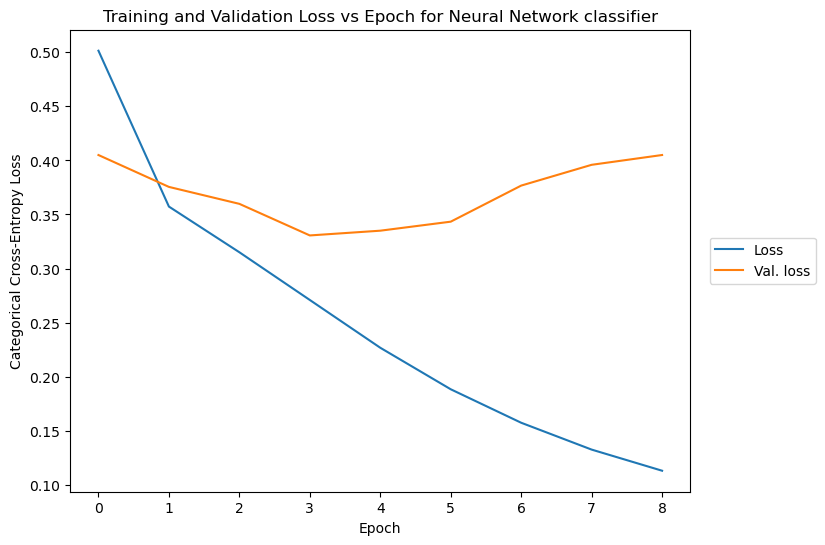

In [11]:
plt.figure(figsize=(8,6))
plt.plot(history_dense.history['loss'], label='Loss')
plt.plot(history_dense.history['val_loss'], label='Val. loss')
plt.title('Training and Validation Loss vs Epoch for Neural Network classifier')
plt.xlabel('Epoch')
plt.ylabel('Categorical Cross-Entropy Loss')
plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=True)
plt.show()

## Deep Sets Classifier

First apply the same fully connected neural network to each track. 
Then the `GlobalAveragePooling1D` layer sums over the tracks (actually it takes the mean) which gives jet level features, then we get the final output. 

In [25]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, BatchNormalization, GlobalAveragePooling1D
import tensorflow.keras.backend as K

# define Deep Sets model with Dense Keras layer
inputs = Input(shape=(ntracks, nfeatures,), name='input')  
x = BatchNormalization(name='bn_1')(inputs)
x = Dense(64, name='dense_1', activation='relu')(x)  #track level network
x = Dense(32, name='dense_2', activation='relu')(x)  #track level network
x = Dense(32, name='dense_3', activation='relu')(x)  #track level network
x = GlobalAveragePooling1D(name='pool_1')(x)  #averages the track to obtain jet level representation
x = Dense(100, name='dense_4', activation='relu')(x) #jet level network
outputs = Dense(nlabels, name='output', activation='softmax')(x)  #final output
keras_model_deepset = Model(inputs=inputs, outputs=outputs)
keras_model_deepset.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print(keras_model_deepset.summary())

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 60, 48)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 60, 48)         │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 60, 64)         │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 60, 32)         │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 60, 32)         │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (GlobalAveragePooling1D) │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │         3,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │           202 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,966 (38.93 KB)

 Trainable params: 9,870 (38.55 KB)

 Non-trainable params: 96 (384.00 B)

None


In [26]:
# define callbacks
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(monitor='val_loss', patience=5)
reduce_lr = ReduceLROnPlateau(patience=5, factor=0.5)
model_checkpoint = ModelCheckpoint('keras_model_deepset_best.weights.h5', monitor='val_loss', save_best_only=True, save_weights_only=True)
callbacks = [early_stopping, model_checkpoint, reduce_lr]

# fit keras model
history_deepset = keras_model_deepset.fit(train_generator, 
                                          validation_data=val_generator, 
                                          steps_per_epoch=len(train_generator), 
                                          validation_steps=len(val_generator),
                                          epochs=20, 
                                          shuffle=False,
                                          callbacks=callbacks, 
                                          verbose=0)
# reload best weights
keras_model_deepset.load_weights('keras_model_deepset_best.weights.h5')

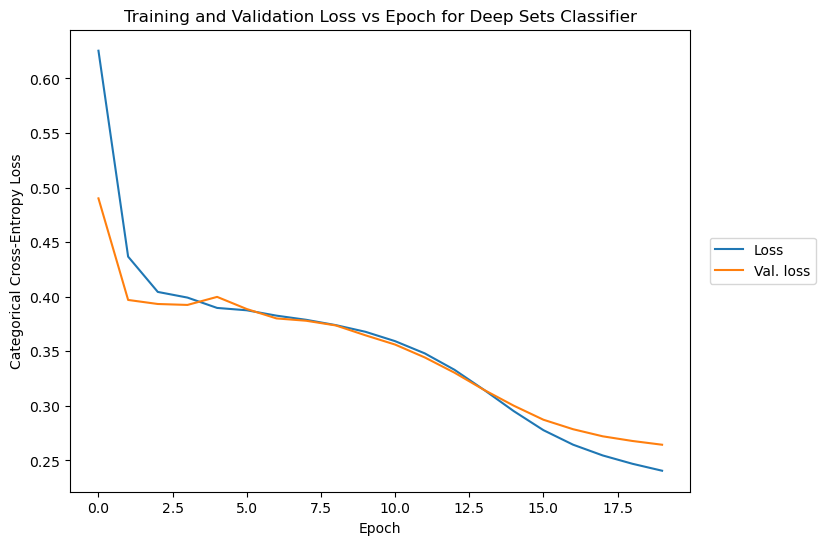

In [27]:
plt.figure(figsize=(8,6))
plt.plot(history_deepset.history['loss'], label='Loss')
plt.plot(history_deepset.history['val_loss'], label='Val. loss')
plt.title('Training and Validation Loss vs Epoch for Deep Sets Classifier')
plt.xlabel('Epoch')
plt.ylabel('Categorical Cross-Entropy Loss')
plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=True)
plt.show()

In [28]:
# load testing file
test_files = ['ntuple_merged_0_test.root']
test_generator = DataGenerator(test_files, features, labels, spectators, batch_size=1024, n_dim=ntracks, 
                               remove_mass_pt_window=True, 
                               remove_unlabeled=True)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
1

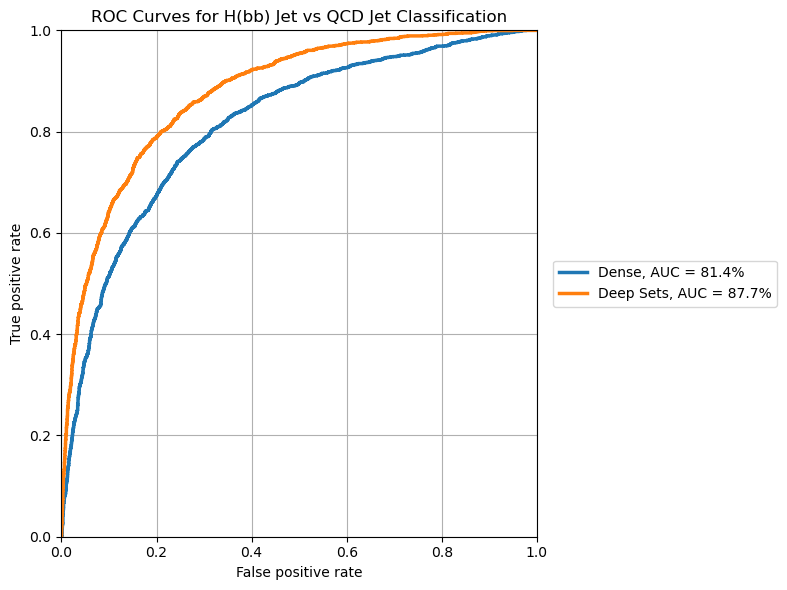

In [29]:
# run model inference on test data set
predict_array_dense = []
predict_array_deepset = []
label_array_test = []

for t in test_generator:
    label_array_test.append(t[1])
    predict_array_dense.append(keras_model_dense.predict(t[0]))
    predict_array_deepset.append(keras_model_deepset.predict(t[0]))
    
    
predict_array_dense = np.concatenate(predict_array_dense, axis=0)
predict_array_deepset = np.concatenate(predict_array_deepset, axis=0)
label_array_test = np.concatenate(label_array_test, axis=0)


# create ROC curves
fpr_dense, tpr_dense, threshold_dense = roc_curve(label_array_test[:,1], predict_array_dense[:,1])
fpr_deepset, tpr_deepset, threshold_deepset = roc_curve(label_array_test[:,1], predict_array_deepset[:,1])
    
# plot ROC curves
plt.figure(figsize=(8,6))
plt.plot(fpr_dense, tpr_dense, lw=2.5, label="Dense, AUC = {:.1f}%".format(auc(fpr_dense, tpr_dense)*100))
plt.plot(fpr_deepset, tpr_deepset, lw=2.5, label="Deep Sets, AUC = {:.1f}%".format(auc(fpr_deepset, tpr_deepset)*100))
plt.xlabel(r'False positive rate')
plt.ylabel(r'True positive rate')
plt.title('ROC Curves for H(bb) Jet vs QCD Jet Classification')
plt.xlim(0,1)
plt.ylim(0,1)
plt.grid(True)
plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=True)
plt.tight_layout()
plt.show()